# KKBox Churn Modeling (v2)

Updates from v1:
- Runs on **Kaggle or local** (auto-detects environment)
- Adds **KNN** as an additional baseline (per teacher feedback)
- Adds proper **threshold tuning** with ROC/PR curve plots
- Adds **KFold cross-validation** for model selection
- LightGBM uses **early stopping**
- **No class reweighting** on tree models — threshold tuning handles imbalance instead
- Programmatic best-model selection

Continues to use the snake_case naming and section structure from
`01_data_exploration.ipynb`.

**Important:** I have not executed this notebook against your data.
Every `# TODO: verify` marker is a spot where you should sanity-check
against your actual file before trusting downstream results.


## 0. Setup

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

RANDOM_STATE = 42


### 0.1 Environment detection

Auto-detects Kaggle vs local. On Kaggle, inputs come from the read-only
`/kaggle/input/` mount and outputs go to `/kaggle/working/` (writable).

In [22]:
print(os.listdir("/kaggle/input/competitions/"))

['kkbox-churn-prediction-challenge']


In [23]:
comp = os.listdir("/kaggle/input/competitions/")[0]
print(f"Competition: {comp}")
print(f"Files: {os.listdir(f'/kaggle/input/competitions/{comp}/')}")

Competition: kkbox-churn-prediction-challenge
Files: ['transactions_v2.csv.7z', 'WSDMChurnLabeller.scala', 'transactions.csv.7z', 'train.csv.7z', 'train_v2.csv.7z', 'user_logs.csv.7z', 'members_v3.csv.7z', 'sample_submission_zero.csv.7z', 'user_logs_v2.csv.7z', 'sample_submission_v2.csv.7z']


In [7]:
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    RAW_DATA_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    MODELS_DIR = "/kaggle/working/"
else:
    RAW_DATA_DIR = "../raw_data/"
    MODELS_DIR = "../models/"

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")
print(f"MODELS_DIR:   {MODELS_DIR}")

if os.path.exists(RAW_DATA_DIR):
    print(f"Files: {os.listdir(RAW_DATA_DIR)}")

Environment: Kaggle
RAW_DATA_DIR: /kaggle/input/competitions/kkbox-churn-prediction-challenge/
MODELS_DIR:   /kaggle/working/
Files: ['transactions_v2.csv.7z', 'WSDMChurnLabeller.scala', 'transactions.csv.7z', 'train.csv.7z', 'train_v2.csv.7z', 'user_logs.csv.7z', 'members_v3.csv.7z', 'sample_submission_zero.csv.7z', 'user_logs_v2.csv.7z', 'sample_submission_v2.csv.7z']


In [8]:
# --- Decompress KKBox archives on Kaggle ---
# The competition ships .csv.7z files. Decompress to /kaggle/working/ once;
# subsequent runs will skip if files already exist.
# TODO: this uses py7zr; alternative is `!apt install p7zip-full && 7z x ...`

if ON_KAGGLE:
    !pip install py7zr --quiet
    import py7zr

    SOURCE_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    EXTRACT_DIR = "/kaggle/working/raw_data/"
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    # Only extract what we actually need (saves time + disk).
    # Using v1 files to match your existing exploration notebook.
    files_to_extract = [
        "train.csv.7z",
        "members_v3.csv.7z",   # note: v3, not "members.csv"
        "transactions.csv.7z",
        # "user_logs.csv.7z",  # ~30GB uncompressed - skip unless needed
    ]

    for fname in files_to_extract:
        out_name = fname.replace(".7z", "")
        out_path = os.path.join(EXTRACT_DIR, out_name)
        if os.path.exists(out_path):
            print(f"Already extracted: {out_name}")
            continue
        src = os.path.join(SOURCE_DIR, fname)
        print(f"Extracting {fname}...")
        with py7zr.SevenZipFile(src, mode="r") as z:
            z.extractall(path=EXTRACT_DIR)
        print(f"  -> {out_path}")

    # Now point RAW_DATA_DIR at the extracted files
    RAW_DATA_DIR = EXTRACT_DIR
    print(f"\nRAW_DATA_DIR is now: {RAW_DATA_DIR}")
    print(f"Files: {os.listdir(RAW_DATA_DIR)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 998.8 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 4.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 7.3 MB/s eta 0:00:00
Extracting train.csv.7z...
  -> /kaggle/working/raw_data/train.csv
Extracting members_v3.csv.7z...
  -> /kaggle/working/raw_data/members_v3.csv
Extracting transactions.csv.7z...
  -> /kaggle/working/raw_data/transactions.csv

RAW_DATA_DIR is now: /kaggle/working/raw_data/
Files: ['transactions.csv', 'members_v3.csv', 'train.csv']


### 0.2 Run configuration

Single source of truth for the cutoff and feature toggles.

In [9]:
# Temporal cutoff for WSDM 2018 v1: train.csv labels = Feb 2017 expirations.
# Features must come from BEFORE this date to avoid leakage.
# TODO: verify against the Kaggle competition page. For v2, use 2017-03-01.
CUTOFF_DATE = pd.Timestamp("2017-02-01") # the prediction moment. Prevents leakage from peeking at the future

# Path to user_logs.csv if available. Set to None to skip.
# TODO: check os.listdir(RAW_DATA_DIR). On Kaggle the file exists by default.
USER_LOGS_PATH = None  # e.g. RAW_DATA_DIR + "user_logs.csv"

# For KNN: train on a sample because full KNN on ~800k rows is impractically slow.
# TODO: increase this if your environment can handle it.
KNN_SAMPLE_SIZE = 100_000


## 1. Load Data

In [31]:
# Memory hint: transactions.csv is ~21M rows. On a 16GB local machine this is fine
# but tight. On Kaggle it's comfortable.
train = pd.read_csv(RAW_DATA_DIR + "train.csv")
members = pd.read_csv(RAW_DATA_DIR + "members_v3.csv")
transactions = pd.read_csv(RAW_DATA_DIR + "transactions.csv")

print(f"train:        {train.shape}") # one row per customer. Our Y
print(f"members:      {members.shape}") 
print(f"transactions: {transactions.shape}")


train:        (992931, 2)
members:      (6769473, 6)
transactions: (21547746, 9)


In [17]:
members.head(5)

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


## 2. Apply Temporal Cutoff

Every feature derived from `transactions` must come from rows dated strictly before `CUTOFF_DATE`. This is what prevents the leakage we
saw in baseline 2 (AUC 0.97 — too good because it peeked at the label).
Features must come from information available at prediction time.

### 2.1 Inspect top-importance features individually. Leaky features - at the top of importance ranking

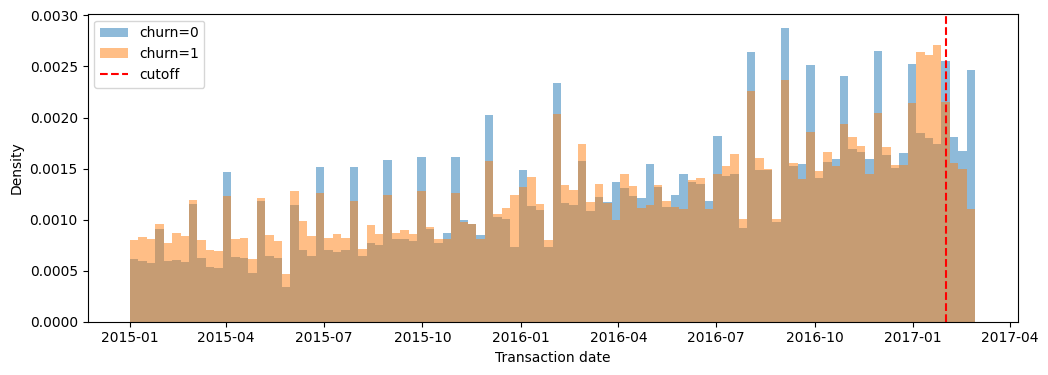

In [29]:
# Ensure dates are datetime
if not pd.api.types.is_datetime64_any_dtype(transactions["transaction_date"]):
    transactions["transaction_date"] = pd.to_datetime(
        transactions["transaction_date"], format="%Y%m%d"
    )

CUTOFF_DATE = pd.Timestamp("2017-02-01")

fig, ax = plt.subplots(figsize=(12, 4))
for churn_val in [0, 1]:
    customer_ids = train.loc[train["is_churn"] == churn_val, "msno"]
    subset = transactions.loc[transactions["msno"].isin(customer_ids), "transaction_date"]
    ax.hist(subset, bins=100, alpha=0.5, label=f"churn={churn_val}", density=True)

ax.axvline(CUTOFF_DATE, color="red", linestyle="--", label="cutoff")
ax.set_xlabel("Transaction date")
ax.set_ylabel("Density")
ax.legend()
plt.show()

In [30]:
# --- Setup (in case prior cells haven't run) ---
CUTOFF_DATE = pd.Timestamp("2017-02-01")

# Ensure transaction_date is datetime
if not pd.api.types.is_datetime64_any_dtype(transactions["transaction_date"]):
    transactions["transaction_date"] = pd.to_datetime(
        transactions["transaction_date"], format="%Y%m%d"
    )
if not pd.api.types.is_datetime64_any_dtype(transactions["membership_expire_date"]):
    transactions["membership_expire_date"] = pd.to_datetime(
        transactions["membership_expire_date"], format="%Y%m%d"
    )

# Build pre-cutoff slice locally
transactions_pre = transactions[transactions["transaction_date"] < CUTOFF_DATE]

# --- Check 3: date sanity ---
print("=== Transaction date sanity ===")
print(f"Max transaction_date in pre-cutoff slice: {transactions_pre['transaction_date'].max()}")
print(f"Cutoff date:                              {CUTOFF_DATE.date()}")
print(f"Rows past cutoff (should be 0):           {(transactions_pre['transaction_date'] >= CUTOFF_DATE).sum():,}")

print(f"\nFor reference:")
print(f"Total rows in transactions:    {len(transactions):,}")
print(f"Rows in transactions_pre:      {len(transactions_pre):,}")
print(f"Rows dropped by cutoff filter: {len(transactions) - len(transactions_pre):,}")

print("\n=== Membership expire date (informational) ===")
print(f"Max membership_expire_date in pre-cutoff slice: {transactions_pre['membership_expire_date'].max()}")
print("Note: this can legitimately be after the cutoff — a transaction in")
print("Jan 2017 can have an expiry in Feb/Mar 2017. What matters is that")
print("transaction_date itself is pre-cutoff (checked above).")

=== Transaction date sanity ===
Max transaction_date in pre-cutoff slice: 2017-01-31 00:00:00
Cutoff date:                              2017-02-01
Rows past cutoff (should be 0):           0

For reference:
Total rows in transactions:    21,547,746
Rows in transactions_pre:      20,639,483
Rows dropped by cutoff filter: 908,263

=== Membership expire date (informational) ===
Max membership_expire_date in pre-cutoff slice: 2017-03-31 00:00:00
Note: this can legitimately be after the cutoff — a transaction in
Jan 2017 can have an expiry in Feb/Mar 2017. What matters is that
transaction_date itself is pre-cutoff (checked above).


In [32]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], format="%Y%m%d"
)
transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"], format="%Y%m%d"
)

transactions_pre = transactions[
    transactions["transaction_date"] < CUTOFF_DATE
].copy()

print(f"total:      {len(transactions):,}")
print(f"pre-cutoff: {len(transactions_pre):,}")
print(f"dropped:    {len(transactions) - len(transactions_pre):,}")


total:      21,547,746
pre-cutoff: 20,639,483
dropped:    908,263


In [33]:
# Should be empty / zero
print(transactions_pre["transaction_date"].max())
# Expected: < 2017-02-01

print((transactions_pre["transaction_date"] >= CUTOFF_DATE).sum())
# Expected: 0

2017-01-31 00:00:00
0


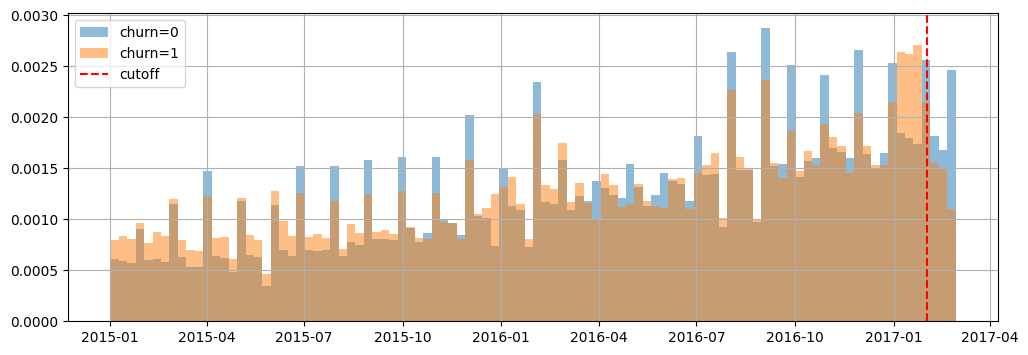

In [34]:
# For example, looking at when transactions happen for churners vs non-churners
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
for churn_val in [0, 1]:
    subset = transactions[transactions["msno"].isin(
        train[train["is_churn"] == churn_val]["msno"]
    )]
    subset["transaction_date"].hist(
        bins=100, alpha=0.5, label=f"churn={churn_val}",
        density=True, ax=ax
    )
ax.axvline(CUTOFF_DATE, color="red", linestyle="--", label="cutoff")
ax.legend()
plt.show()

## 3. Cleaning & Feature Engineering

### 3.1 Members features

In [35]:
members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [36]:
members["registration_init_time"] = pd.to_datetime(
    members["registration_init_time"], format="%Y%m%d" # convert registration date
)

#create a feature
members["tenure_days"] = (CUTOFF_DATE - members["registration_init_time"]).dt.days # for each customer, calculate how many days passed btw reg and cutoff

# bd (age) in KKBox is dirty. Clip and add a missing-indicator.
# TODO: plot members["bd"].describe() to confirm the 10-80 range is sensible.
members["bd_clean"] = members["bd"].where(
    (members["bd"] >= 10) & (members["bd"] <= 80)
)
members["bd_was_invalid"] = members["bd_clean"].isna().astype(int)
members["gender_filled"] = members["gender"].fillna("Unknown")

members_features = members[[
    "msno",
    "city",
    "bd_clean",
    "bd_was_invalid",
    "gender_filled",
    "registered_via",
    "tenure_days",
]].copy()

print(f"bd_clean missing rate: {members_features['bd_clean'].isna().mean():.2%}")
members_features.head()


bd_clean missing rate: 67.22%


,msno,city,bd_clean,bd_was_invalid,gender_filled,registered_via,tenure_days
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,NaN,1,Unknown,11,1970
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,NaN,1,Unknown,7,1967
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,NaN,1,Unknown,11,1966
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,NaN,1,Unknown,11,1966
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32.0,0,female,9,1966


### 3.2 Transaction aggregate features

Aggregate over the user's entire pre-cutoff history rather than taking
only the latest transaction. `n_cancels_before_cutoff` replaces the
leaky `is_cancel` from baseline 2 — cancellation history is legitimate
signal; cancellation at the labeling moment is the label.

In [4]:
transactions_pre.head(5)

NameError: name 'transactions_pre' is not defined

In [5]:
#last transaction
last_txn = transactions_pre.groupby("msno")["transaction_date"].max()

#create a feature - days since last transactions
days_since_last_txn = (CUTOFF_DATE - last_txn).dt.days.rename("days_since_last_txn")

last_expire = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["membership_expire_date"]
)
days_until_expiry_at_cutoff = (last_expire - CUTOFF_DATE).dt.days.rename(
    "days_until_expiry_at_cutoff"
)

txn_agg = transactions_pre.groupby("msno").agg(
    n_transactions=("transaction_date", "count"),
    n_cancels_before_cutoff=("is_cancel", "sum"),
    mean_actual_paid=("actual_amount_paid", "mean"),
    sum_actual_paid=("actual_amount_paid", "sum"),
    mean_list_price=("plan_list_price", "mean"),
    mean_plan_days=("payment_plan_days", "mean"),
    mean_auto_renew=("is_auto_renew", "mean"),
    n_unique_payment_methods=("payment_method_id", "nunique"),
)
txn_agg["discount_ratio"] = np.where(
    txn_agg["mean_list_price"] > 0,
    txn_agg["mean_actual_paid"] / txn_agg["mean_list_price"],
    1.0,
)

latest_payment_method = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["payment_method_id"]
    .rename("latest_payment_method_id")
)

transaction_features = (
    txn_agg
    .join(days_since_last_txn)
    .join(days_until_expiry_at_cutoff)
    .join(latest_payment_method)
    .reset_index()
)

print(f"shape: {transaction_features.shape}")
transaction_features.head()


NameError: name 'transactions_pre' is not defined

### 3.3 User logs features (optional, large file)

If `user_logs.csv` is available, aggregate listening behavior in the
30 days before cutoff. Skipped by default because the file is large
(~30GB uncompressed — verify).

**Safe loading on Kaggle:** the cell uses dtype hints and column
subsetting to keep memory in check. If you still OOM, switch to
chunked loading.

In [ ]:
if USER_LOGS_PATH is not None:
    # Read with dtype hints to reduce memory.
    # TODO: confirm column names with pd.read_csv(USER_LOGS_PATH, nrows=5).columns
    dtypes = {
        "msno": "object",
        "num_25": "int32",
        "num_50": "int32",
        "num_75": "int32",
        "num_985": "int32",
        "num_100": "int32",
        "num_unq": "int32",
        "total_secs": "float32",
    }
    user_logs = pd.read_csv(
        USER_LOGS_PATH,
        dtype=dtypes,
        parse_dates=["date"],
        date_format="%Y%m%d",
    )

    window_start = CUTOFF_DATE - pd.Timedelta(days=30)
    logs_window = user_logs[
        (user_logs["date"] >= window_start) & (user_logs["date"] < CUTOFF_DATE)
    ]

    log_features = logs_window.groupby("msno").agg(
        active_days_30d=("date", "nunique"),
        total_secs_30d=("total_secs", "sum"),
        mean_unique_songs_30d=("num_unq", "mean"),
        total_skips_30d=("num_25", "sum"),
        total_completed_30d=("num_100", "sum"),
    ).reset_index()

    log_features["skip_ratio_30d"] = np.where(
        (log_features["total_skips_30d"] + log_features["total_completed_30d"]) > 0,
        log_features["total_skips_30d"]
        / (log_features["total_skips_30d"] + log_features["total_completed_30d"]),
        np.nan,
    )
    print(log_features.head())
    print(f"shape: {log_features.shape}")
else:
    log_features = None
    print("user_logs.csv not configured. Skipping log features.")


## 4. Assemble Final Dataset

In [ ]:
df = train.merge(members_features, on="msno", how="left")
df = df.merge(transaction_features, on="msno", how="left")
if log_features is not None:
    df = df.merge(log_features, on="msno", how="left")

print(f"shape:      {df.shape}")
print(f"churn rate: {df['is_churn'].mean():.2%}")
print(f"\nmissing rates (top 10):")
print(df.isna().mean().sort_values(ascending=False).head(10))


## 5. Train / Test Split

In [ ]:
y = df["is_churn"]
X = df.drop(columns=["is_churn", "msno"])

categorical_features = [
    "city",
    "gender_filled",
    "registered_via",
    "latest_payment_method_id",
]
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"numeric:     {len(numeric_features)} cols")
print(f"categorical: {len(categorical_features)} cols")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f"\nX_train: {X_train.shape}  churn: {y_train.mean():.2%}")
print(f"X_test:  {X_test.shape}  churn: {y_test.mean():.2%}")


## 6. Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## 7. Evaluation Helpers

Compute the metric suite *and* return enough state to drive threshold
tuning later. Note we now keep `y_proba` for later analysis instead of
throwing it away.

In [ ]:
def compute_metrics(name, y_true, y_proba, threshold=0.5):
    """Compute the full metric suite at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)

    # Recall at top decile (threshold-independent, business-relevant)
    k = int(0.1 * len(y_true))
    top_k_idx = np.argsort(y_proba)[::-1][:k]
    y_true_arr = np.asarray(y_true)
    recall_at_10 = y_true_arr[top_k_idx].sum() / y_true_arr.sum()

    return {
        "name": name,
        "threshold": threshold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "recall_at_10": recall_at_10,
    }


def report_model(name, y_true, y_proba, threshold=0.5):
    """Print the metric suite and return it."""
    m = compute_metrics(name, y_true, y_proba, threshold)
    print(f"================ {name} (threshold={threshold:.2f}) ================")
    print(classification_report(y_true, (y_proba >= threshold).astype(int)))
    print(f"ROC-AUC:           {m['roc_auc']:.4f}")
    print(f"PR-AUC:            {m['pr_auc']:.4f}")
    print(f"F1:                {m['f1']:.4f}")
    print(f"Recall @ top 10%:  {m['recall_at_10']:.4f}")
    print()
    return m


## 8. Trivial Baseline (sanity check)

What do "AUC = 0.5" and "always predict majority" actually look like
on this data? Useful reference point — if your model isn't beating
this comfortably, something is wrong.

In [ ]:
# Always predict the majority class (no churn)
y_proba_trivial = np.full(len(y_test), y_train.mean())
trivial_metrics = report_model("Trivial (predict base rate)", y_test, y_proba_trivial)


## 9. Model 1: Logistic Regression

In [ ]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

lr_model.fit(X_train, y_train)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
lr_metrics = report_model("Logistic Regression", y_test, y_proba_lr)


## 10. Model 2: KNN (per teacher feedback)

**Honest note:** KNN is a poor fit for this problem. Three reasons:
1. Prediction is O(n_train) per query — slow on ~800k training rows.
2. Mixed feature types (scaled numeric + one-hot categorical) make
   Euclidean distance noisy.
3. With 6% positives, most neighborhoods are dominated by negatives,
   so KNN tends to under-predict the positive class.

We train on a sample (`KNN_SAMPLE_SIZE`) to keep runtime reasonable.
Expect KNN to lose meaningfully to LR and LightGBM. That's instructive.

In [ ]:
# Sample for KNN
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_train), size=min(KNN_SAMPLE_SIZE, len(X_train)), replace=False)
X_train_knn = X_train.iloc[sample_idx]
y_train_knn = y_train.iloc[sample_idx]

print(f"KNN training sample: {len(X_train_knn):,} rows "
      f"(churn rate: {y_train_knn.mean():.2%})")

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=25,           # TODO: try a few values; 5/15/25/50
        weights="distance",       # closer neighbors count more
        n_jobs=-1,
    )),
])

knn_model.fit(X_train_knn, y_train_knn)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]
knn_metrics = report_model("KNN (k=25, distance-weighted)", y_test, y_proba_knn)


## 11. Model 3: LightGBM

Workhorse model for tabular churn. Two design choices worth noting:

- **No `is_unbalance`/`scale_pos_weight`.** With class reweighting on,
  the model's probability outputs get pulled toward 0.5 and threshold
  tuning gets confused. Cleaner: leave probabilities natural, then
  tune the threshold (Section 12) to hit the desired
  precision/recall tradeoff.
- **Early stopping** on a held-out slice so we don't waste trees.

In [ ]:
# Carve a validation slice out of training data for early stopping.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Fit the preprocessor on the training slice, transform both
preprocessor_lgbm = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
X_tr_t = preprocessor_lgbm.fit_transform(X_tr)
X_val_t = preprocessor_lgbm.transform(X_val)
X_test_t = preprocessor_lgbm.transform(X_test)

lgbm = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm.fit(
    X_tr_t, y_tr,
    eval_set=[(X_val_t, y_val)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100),
    ],
)

print(f"\nBest iteration: {lgbm.best_iteration_}")
y_proba_lgbm = lgbm.predict_proba(X_test_t)[:, 1]
lgbm_metrics = report_model("LightGBM", y_test, y_proba_lgbm)


## 12. Threshold Tuning

The default 0.5 threshold is almost always wrong for imbalanced
problems. We have two ways to pick a better one:

1. **Optimize a metric** (e.g., maximize F1). Generic, no business
   context required.
2. **Apply a cost model** (cost of false positive vs cost of false
   negative). Better when you have those numbers.

Below: maximize F1 on the test set for each model. For production,
you should pick the threshold on a *validation* set and report it on
a held-out test set — what's shown here is a simplification suitable
for the bootcamp deliverable.

In [ ]:
def best_threshold_for_f1(y_true, y_proba, n_thresholds=200):
    """Sweep thresholds and return the one that maximizes F1."""
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx], thresholds, f1s


def plot_threshold_sweep(name, y_true, y_proba, ax):
    """Plot precision, recall, F1 across thresholds."""
    thresholds = np.linspace(0.01, 0.99, 99)
    precisions = []
    recalls = []
    f1s = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, f1s, label="F1", linewidth=2)
    best_t = thresholds[int(np.argmax(f1s))]
    ax.axvline(best_t, linestyle="--", color="gray", alpha=0.6,
               label=f"Best F1 @ {best_t:.2f}")
    ax.set_title(name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)


In [ ]:
# Sweep + plot for each real model (skip the trivial baseline)
model_probas = {
    "Logistic Regression": y_proba_lr,
    "KNN": y_proba_knn,
    "LightGBM": y_proba_lgbm,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_proba) in zip(axes, model_probas.items()):
    plot_threshold_sweep(name, y_test, y_proba, ax)
plt.tight_layout()
plt.show()


In [ ]:
# Print the F1-optimal threshold and re-report metrics there
tuned_results = []
for name, y_proba in model_probas.items():
    best_t, best_f1, _, _ = best_threshold_for_f1(y_test, y_proba)
    print(f"{name}: best F1 = {best_f1:.4f} at threshold = {best_t:.3f}")
    tuned_results.append(compute_metrics(name, y_test, y_proba, threshold=best_t))

tuned_df = pd.DataFrame(tuned_results)
print()
print(tuned_df.to_string(index=False))


## 13. ROC and PR Curves

The curves are how you actually *see* the tradeoffs. PR curve is more
informative than ROC for a 6% positive rate — pay more attention to it.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
for name, y_proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR
for name, y_proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4,
                label=f"Base rate ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 14. Cross-Validation Sanity Check

A single train/test split tells you what one specific shuffle looked
like. KFold tells you how stable the result is. Run on the winning
model (LightGBM, most likely) for a confidence check.

In [ ]:
# Quick CV on LightGBM. Use the full pipeline so preprocessing is fit per fold.
# Note: this re-trains the model 5x, so it's slow. Skip if time-constrained.

lgbm_pipeline_cv = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])),
    ("classifier", LGBMClassifier(
        n_estimators=lgbm.best_iteration_ or 500,
        learning_rate=0.05,
        num_leaves=63,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    lgbm_pipeline_cv, X_train, y_train,
    cv=cv, scoring="roc_auc", n_jobs=-1,
)
print(f"LightGBM ROC-AUC across 5 folds: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")


## 15. Final Comparison

In [ ]:
all_results = pd.DataFrame([
    trivial_metrics,
    lr_metrics,
    knn_metrics,
    lgbm_metrics,
] + tuned_results)

# Tag which rows are tuned-threshold vs default-threshold
all_results["tuned"] = all_results["threshold"] != 0.5

print(all_results.to_string(index=False))


## 16. Feature Importance (LightGBM)

In [ ]:
feature_names = preprocessor_lgbm.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm.feature_importances_,
}).sort_values("importance", ascending=False)

print(importance_df.head(20).to_string(index=False))

# Quick plot
top_20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20["feature"][::-1], top_20["importance"][::-1])
ax.set_xlabel("Importance (LightGBM gain)")
ax.set_title("Top 20 Features")
plt.tight_layout()
plt.show()


## 17. Save Best Model

Programmatically picks the best model by PR-AUC (better than ROC-AUC
for imbalanced classes) and saves it.

In [ ]:
import joblib

candidates = {
    "logistic_regression": (lr_model, lr_metrics["pr_auc"]),
    "knn": (knn_model, knn_metrics["pr_auc"]),
    "lightgbm": (lgbm, lgbm_metrics["pr_auc"]),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_model, best_pr_auc = candidates[best_name]

best_path = MODELS_DIR + f"kkbox_churn_{best_name}.pkl"
joblib.dump(best_model, best_path)
print(f"Best model: {best_name} (PR-AUC = {best_pr_auc:.4f})")
print(f"Saved to:   {best_path}")

# Also save the preprocessor if the best is LightGBM (which we trained
# outside a pipeline so it can use early stopping).
if best_name == "lightgbm":
    preproc_path = MODELS_DIR + "kkbox_churn_lightgbm_preprocessor.pkl"
    joblib.dump(preprocessor_lgbm, preproc_path)
    print(f"Preprocessor: {preproc_path}")


## 18. Next Steps

What this scaffold deliberately doesn't do:

1. **Hyperparameter tuning** on LightGBM via Optuna. Focus params:
   `num_leaves`, `learning_rate`, `min_child_samples`, `reg_alpha`,
   `reg_lambda`.
2. **Probability calibration** via `CalibratedClassifierCV` if the
   probabilities will be shown to business users (per your deck mock).
3. **SHAP** for per-customer explanations (the "AI explanation" panel
   in your UI mock).
4. **`user_logs` features** if you have the file. Likely the biggest
   single source of additional signal.
5. **Cross-window validation**: train on v1 (Feb 2017), test on v2
   (March 2017) for a more rigorous time-based evaluation.
6. **Cost-based threshold selection** if you can put numbers on the
   cost of a retention campaign vs the value of a retained customer.
